# Data Cleaning Notebook

In [ ]:
# install packages if necessary
%pip install pandas geopandas matplotlib plotly 

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import zipfile

## The `load_data()` function

- Loads in city data, the [geojson file](https://data.sfgov.org/Geographic-Locations-and-Boundaries/Bay-Area-County-Polygons/wamw-vt4s/data_preview), and crash data
- Converts data to have valid coordinates
- Returns all files

In [ ]:
def load_data(stop_path, geo_path, crash_path):
    
    # unzip stop and crash data
    with zipfile.ZipFile(stop_path) as z:
        csv_file = [f for f in z.namelist() if f.endswith(".csv")][0]
        df = pd.read_csv(z.open(csv_file))
    with zipfile.ZipFile(crash_path) as z:
        csv_file = [f for f in z.namelist() if f.endswith(".csv")][0]
        crash_df = pd.read_csv(z.open(csv_file))
    

    # get boundaries of city 
    city_df = gpd.read_file(geo_path)
    
    # get locations of all stops, crashes from the city's dataset
    stops_df = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lng"], df["lat"]),
        crs="EPSG:4326"
    )
    crash_df = gpd.GeoDataFrame(
        crash_df,
        geometry=gpd.points_from_xy(crash_df["tb_longitude"], crash_df["tb_latitude"]),
        crs="EPSG:4326"
    )
    
    # Print coordinate reference system to verify correct locations
    print("Shapefile CRS:", city_df.crs)
    print("Police Stop Data CRS:", stops_df.crs)
    print("Collision Data CRS:", crash_df.crs)
    
    return city_df, stops_df, crash_df

1. We manually add in the pathname for the Bay Area counties <font color='red'>(source?)</font> to see the extent of counties local to San Francisco. 
2. We also add the pathname for the [Stanford Open Policing project data](https://github.com/stanford-policylab/opp/blob/master/data_readme.md) and [San Francisco Traffic Crash dataset](https://data.sfgov.org/Public-Safety/Traffic-Crashes-Resulting-in-Injury/ubvf-ztfx/about_data) to obtain coordinates where stops and crashes occurred.

*Loading this data will assist us in determining if the coordinates logged in the Stanford Open Policing project data have been logged improperly or are irrelevant to our analyses.*

In [104]:
# change path names based on city/dataset
stop_df_path = r"../data/sf_police_stops_raw.csv.zip"
geo_path = r"../data/Bay_Area_County_Polygons.geojson"
crash_df_path = r"../data/collisions_raw.csv.zip"

# load and view example data
city_boundaries, stops_df, crash_df = load_data(stop_df_path, geo_path, crash_df_path)

city_boundaries.head()
stops_df.head()
crash_df.head()


/var/folders/6l/_5f2v6_x5hj1cd_lrwrm8k9r0000gn/T/ipykernel_65901/1439134997.py:6: DtypeWarning:

Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.



Shapefile CRS: EPSG:4326
Police Stop Data CRS: EPSG:4326
Collision Data CRS: EPSG:4326


,unique_id,cnn_intrsctn_fkey,cnn_sgmt_fkey,case_id_pkey,tb_latitude,tb_longitude,geocode_source,geocode_location,collision_datetime,collision_date,...,party2_dir_of_travel,party2_move_pre_acc,point,data_as_of,data_updated_at,data_loaded_at,analysis_neighborhood,supervisor_district,police_district,geometry
0,8099,22339000,10611201.0,2917572,37.747784,-122.444159,SFPD-CROSSROADS,CITY STREET,2006 Dec 01 12:51:00 AM,2006 December 01,...,West,Not Stated,POINT (-122.444158744 37.747783889),2006 Dec 01 12:00:00 AM,2023 Apr 26 12:00:00 AM,2025 Dec 30 10:40:20 AM,Twin Peaks,8.0,MISSION,POINT (-122.44416 37.74778)
1,601,20454000,NaN,2917560,37.722035,-122.393172,SFPD-CROSSROADS,CITY STREET,2006 Dec 01 02:20:00 AM,2006 December 01,...,East,Proceeding Straight,POINT (-122.393171958 37.722034717),2006 Dec 01 12:00:00 AM,2023 Apr 26 12:00:00 AM,2025 Dec 30 10:40:20 AM,Bayview Hunters Point,10.0,BAYVIEW,POINT (-122.39317 37.72203)
2,23156,24583000,170000.0,2945603,37.783463,-122.398527,SFPD-CROSSROADS,CITY STREET,2006 Dec 01 06:22:00 AM,2006 December 01,...,North,Proceeding Straight,POINT (-122.398526901 37.783463366),2006 Dec 01 12:00:00 AM,2023 Apr 26 12:00:00 AM,2025 Dec 30 10:40:20 AM,South of Market,6.0,SOUTHERN,POINT (-122.39853 37.78346)
3,15409,24264000,5671000.0,2922344,37.777384,-122.407035,SFPD-CROSSROADS,CITY STREET,2006 Dec 01 08:25:00 AM,2006 December 01,...,East,Proceeding Straight,POINT (-122.407034911 37.777383709),2006 Dec 01 12:00:00 AM,2023 Apr 26 12:00:00 AM,2025 Dec 30 10:40:20 AM,South of Market,6.0,SOUTHERN,POINT (-122.40703 37.77738)
4,3043,20961000,11908000.0,2917580,37.728803,-122.416918,SFPD-CROSSROADS,CITY STREET,2006 Dec 01 11:41:00 AM,2006 December 01,...,West,Proceeding Straight,POINT (-122.416917976 37.728803467),2006 Dec 01 12:00:00 AM,2023 Apr 26 12:00:00 AM,2025 Dec 30 10:40:20 AM,Portola,9.0,BAYVIEW,POINT (-122.41692 37.7288)


## Visualizing Raw Data Before Preprocessing

Before making any changes to the data, we want to see what it looks like to determine what preprocessing steps are necessary for our geospatial data processing pipeline. 

In [64]:
import plotly.express as px
import plotly.graph_objects as go
import json
import plotly.io as pio
pio.renderers.default = "browser"

In [ ]:
# Plot heatmap to show distribution of crashes and collisions from raw data
geojson = city_boundaries.__geo_interface__

# plot baselayer
fig = px.choropleth_map(
    city_boundaries,
    geojson=geojson,
    locations=city_boundaries.index,
    color_discrete_sequence=["lightgray"],
    map_style="carto-positron",
    zoom=8,
    center={"lat": 37.77, "lon": -122.42},
    opacity=0.4
)

# Police stop density
fig.add_trace(
    go.Densitymap(
        lat=stops_df.geometry.y,
        lon=stops_df.geometry.x,
        radius=5,
        colorscale="Blues",
        opacity=0.6,
        hoverinfo="skip",
        showscale=False,
        name="Stops"
    )
)

# Crash density
fig.add_trace(
    go.Densitymap(
        lat=crash_df.geometry.y,
        lon=crash_df.geometry.x,
        radius=5,
        opacity=0.6,
        hoverinfo="skip",
        showscale=False,
        name="Crashes"
    )
)

fig.update_layout(
    title="Police Stops and Collisions Density",
    hovermode=False,
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()

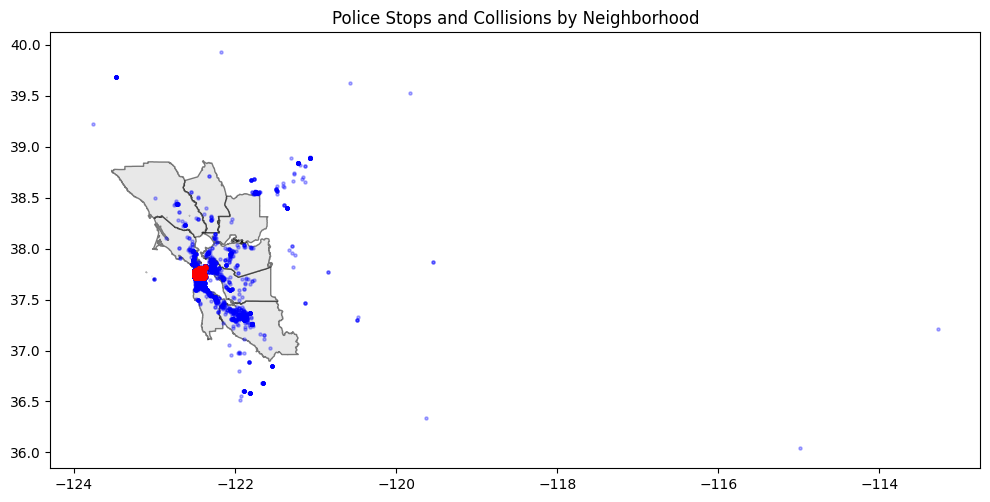

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(12, 10))
# plot bay area county boundaries
city_boundaries.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
# color county=='San Francisco' in city_boundaries a different color

# add stops and collisions
stops_df.plot(ax=ax, color='blue', markersize=5, alpha=0.3)
crash_df.plot(ax=ax, color='red', markersize=5, alpha=0.3)
plt.title("Police Stops and Collisions by Neighborhood")
plt.show()

We can see that there are several coordinates outside of the extent of San Francisco County. 
This leads us to believe these points have been recorded incorrectly and should be removed from data before modeling. 

In [87]:
# Check a few coordinates
print(stops_df.head()[['geometry']])
print("\nBounds of shapefile:", city_boundaries.total_bounds)
print("Bounds of points:", stops_df.total_bounds)

                      geometry
0    POINT (-122.44587 37.773)
1   POINT (-122.46859 37.7809)
2  POINT (-122.42672 37.78692)
3    POINT (-122.392 37.74638)
4     POINT (-122.44 37.78635)

Bounds of shapefile: [-123.53367    36.894155 -121.208178   38.864245]
Bounds of points: [-123.7674293   36.038676  -113.2681513   39.929646 ]


In [88]:
print("Total points:", len(stops_df))
print("Points outside shapefile bounds:", 
      ((stops_df.geometry.x < -123.6) | (stops_df.geometry.x > -121.0) |
       (stops_df.geometry.y < 36.8) | (stops_df.geometry.y > 39.0)).sum())

Total points: 905070
Points outside shapefile bounds: 97


## Preprocess Non Location Variables

In [90]:
#View number of variable outcome per variable of intreset
#suggests dropping search_basis and contraband_found
variables = ['district', 'outcome', 'subject_race', 'subject_sex', 'type', 'reason_for_stop', 'raw_search_vehicle_description', 'raw_result_of_contact_description']

for v in variables:
    print(stops_df.groupby(v).size())

district
A     69677
B    105867
C     95406
D     87702
E     73846
F     61713
G     85276
H    117520
I    108213
J     46171
K       783
S       514
T       195
dtype: int64
outcome
arrest       11925
citation    631602
warning     245862
dtype: int64
subject_race
asian/pacific islander    157684
black                     152196
hispanic                  116014
other                     106858
white                     372318
dtype: int64
subject_sex
female    265851
male      639219
dtype: int64
type
vehicular    905070
dtype: int64
reason_for_stop
Assistance to Motorist                                                                                                                                                                         930
BOLO/APB/Warrant                                                                                                                                                                              1207
DUI Check                                         

Based on tabling, the following is suggested:
*  Only keep following for raw vehicle description: 'Vehicle Inventory, Positive Result', 'Vehicle Inventory, Negative Result', 'Searched as a result of Probation or Parole Condition', 'Search without Consent, Positive Result', 'Search without Consent, Negative Result', 'Search with Consent, Positive Result', 'Search with Consent, Negative Result', 'Search Incident to Arrest, Positive Result', 'Search Incident to Arrest, Negative Result', 'No Search'
*  Only keep following for reason for stop: 'Traffic Collision', 'Moving Violation', 'MPC Violation', 'DUI Check', 'BOLO/APB/Warrant', 'Assistance to Motorist'

Note the raw vehicle description helps dervive search outcome (based on if it's postive or negative outcome)

In [105]:
#Filter out values in raw vehicle description
raw_vehicle_desc_keep = ['Vehicle Inventory, Positive Result', 'Vehicle Inventory, Negative Result', 'Searched as a result of Probation or Parole Condition', 'Search without Consent, Positive Result', 'Search without Consent, Negative Result', 'Search with Consent, Positive Result', 'Search with Consent, Negative Result', 'Search Incident to Arrest, Positive Result', 'Search Incident to Arrest, Negative Result', 'No Search']
stops_clean = stops_df[stops_df['raw_search_vehicle_description'].isin(raw_vehicle_desc_keep)]

raw_reason_for_stop = ['Traffic Collision', 'Moving Violation', 'MPC Violation', 'DUI Check', 'BOLO/APB/Warrant', 'Assistance to Motorist']
stops_clean = stops_df[stops_df['reason_for_stop'].isin(raw_reason_for_stop)]

Now lets filter out NA in  'subject_age', 'time', 'district'

In [106]:
stops_clean = stops_clean.dropna(subset = ['subject_age', 'time', 'district'])

In [107]:
stops_clean.head()

,raw_row_number,date,time,location,lat,lng,district,subject_age,subject_race,subject_sex,...,warning_issued,outcome,contraband_found,search_conducted,search_vehicle,search_basis,reason_for_stop,raw_search_vehicle_description,raw_result_of_contact_description,geometry
33160,31,2007-01-01,10:17:00,EMBARCADERO & HOWARDA ON,37.792563,-122.390973,B,32.0,white,male,...,False,citation,NaN,False,False,NaN,Moving Violation,No Search,Citation,POINT (-122.39097 37.79256)
33161,32,2007-01-01,10:25:00,1700 JUDAH,37.761562,-122.480251,I,57.0,asian/pacific islander,female,...,False,citation,NaN,False,False,NaN,Moving Violation,No Search,Citation,POINT (-122.48025 37.76156)
33162,33,2007-01-01,10:28:00,COLUMBUS/VALLEJO,37.798712,-122.407910,A,31.0,hispanic,male,...,True,warning,NaN,False,False,NaN,Moving Violation,No Search,Warning,POINT (-122.40791 37.79871)
33163,34,2007-01-01,10:35:00,FOLSOM & MOSS,37.777182,-122.407335,J,37.0,hispanic,female,...,False,citation,NaN,False,False,NaN,Moving Violation,No Search,Citation,POINT (-122.40734 37.77718)
33164,35,2007-01-01,10:40:00,WASHINGTON/VAN NESS,37.793076,-122.422808,E,39.0,asian/pacific islander,female,...,False,citation,NaN,False,False,NaN,Moving Violation,No Search,Citation,POINT (-122.42281 37.79308)


## The `fix_coordinates()` function (Preprocess Location)

- Takes in the stop dataset and the city boundaries
- Calculates the bounds of the city
- Filters out points in the stop dataset that aren't within the city boundaries
- Returns a cleaned dataset

There needs to be more research in this section. There are still some points that don't line up (not sure why). Maybe look into the data set if they have anything in common and if they will be filtered out when we narrow down our data set to see the impact of Vision Zero.

Since we are only interested in San Francisco County, we add it to our counties of interest in order to filter out data from other counties. 

In [108]:
# filter city to county of interest
counties_of_interest = ["San Francisco"]

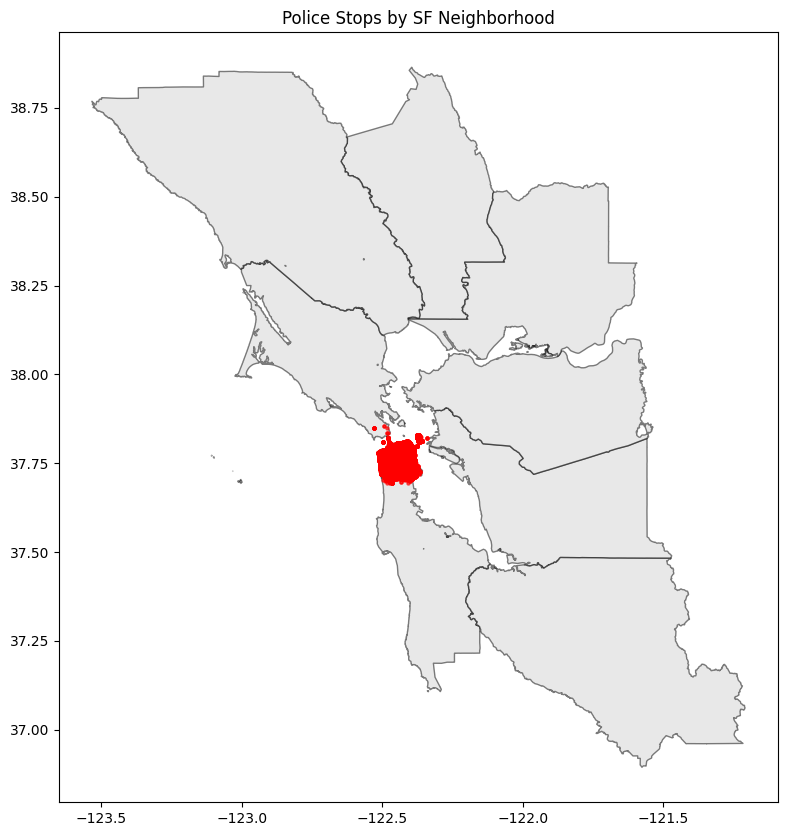

In [109]:
def fix_coordinates(stop_df, city_boundaries, counties_of_interest):

    # only keep data within relevant counties
    city_boundaries = city_boundaries[city_boundaries['county'].isin(counties_of_interest)]
    
    # Get sf (geojson bounds) and filter points
    minx, miny, maxx, maxy = city_boundaries.total_bounds
    stops_clean = stop_df[
    (stop_df.geometry.x >= minx) & 
    (stop_df.geometry.x <= maxx) &
    (stop_df.geometry.y >= miny) & 
    (stop_df.geometry.y <= maxy)
]
    
    return stops_clean

stops_clean = fix_coordinates(stops_clean, city_boundaries, counties_of_interest)

# Now plot with clean data
fig, ax = plt.subplots(figsize=(12, 10))
city_boundaries.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
stops_clean.plot(ax=ax, color='red', markersize=5, alpha=0.6)
plt.title("Police Stops by SF Neighborhood")
plt.show()   

### Processing the Crash Dataset

- keep processing separate or together?
- clean out crashes in similar manner